In [1]:
#run the following for the first time
# try:
#     %pip install --user "oracledb" --no-warn-script-location
# except Exception as e:
#     print("\x1b[31m\u2717 Unexpected error! Please contact course staff\n" +
#          "Please include the entire text above and below in your message.")
#     raise

In [2]:
import oracledb
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_lukeni", password="a54131032", dsn=dsn)

In [4]:
cur = connection.cursor()

In [5]:

# Define the grouped SQL query

query_line = """
SELECT year_quarter, SUM(COUNT) AS COUNT
FROM (
    SELECT year_quarter, SUM(total_bene_telehealth) AS COUNT
    FROM BENEFICIARY
    WHERE year_quarter NOT IN ('2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall')
    GROUP BY year_quarter

    UNION ALL

    SELECT year_quarter, SUM(service_count) AS COUNT
    FROM SERVICECOUNT
    WHERE service_type != 'Store and forward'
    GROUP BY year_quarter

    UNION ALL
    SELECT year_quarter, COUNT(*) AS COUNT
    FROM PATIENTS
    GROUP BY year_quarter
)
GROUP BY year_quarter
ORDER BY year_quarter

"""


# Execute and fetch results into pandas DataFrame
cur.execute(query_line)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
line = pd.DataFrame(rows, columns=columns)

# Display the result
print(line)


   YEAR_QUARTER        COUNT
0        2018-1     539453.0
1        2018-2     581662.0
2        2018-3     650173.0
3        2018-4     730911.0
4        2019-1     849254.0
5        2019-2     896298.0
6        2019-3     934079.0
7        2019-4    1015466.0
8        2020-1   42673482.5
9        2020-2  269998027.5
10       2020-3  184078129.0
11       2020-4  182539105.5
12       2021-1  173561909.0
13       2021-2  124878053.0
14       2021-3  109592065.0
15       2021-4  106458687.0
16       2022-1  120600628.0
17       2022-2   98527157.5
18       2022-3   95720006.0
19       2022-4   94726537.0
20       2023-1   70334406.0
21       2023-2   62096082.0
22       2023-3   60349187.0
23       2023-4   63085068.5
24       2024-1   63933842.0
25       2024-2   59093042.0


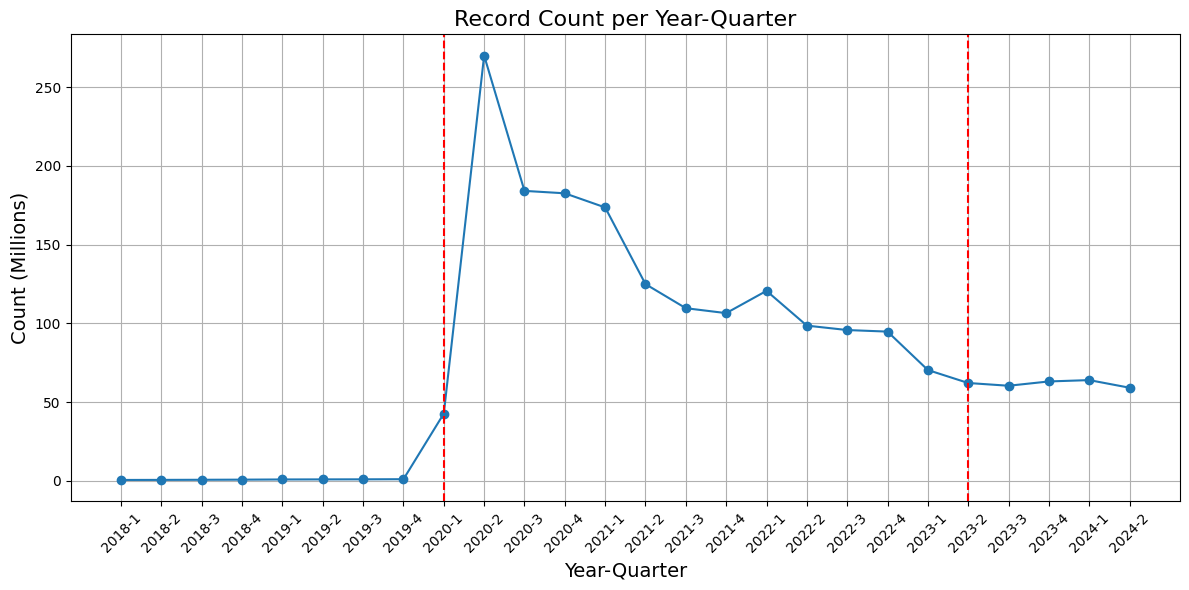

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(line['YEAR_QUARTER'], line['COUNT'] / 1e6, marker='o')

# Customize axis labels with increased font size
plt.title('Record Count per Year-Quarter', fontsize=16)
plt.xlabel('Year-Quarter', fontsize=14)
plt.ylabel('Count (Millions)', fontsize=14)

# Add red vertical dotted lines
plt.axvline(x='2020-1', color='red', linestyle='--', linewidth=1.5)
plt.axvline(x='2023-2', color='red', linestyle='--', linewidth=1.5)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save plot to figures folder
#plt.savefig('figures/line_chart.png', dpi=300)

# Show plot
plt.show()


In [13]:


query_avg = """
SELECT
  CASE
    WHEN year_quarter BETWEEN '2018-1' AND '2019-4' THEN 'Pre-Pandemic'
    WHEN year_quarter BETWEEN '2020-1' AND '2023-1' THEN 'During Pandemic'
    WHEN year_quarter >= '2023-2' THEN 'Post-Pandemic'
  END AS PERIOD,
  AVG(COUNT) AS AVG_COUNT
FROM (
  SELECT year_quarter, SUM(COUNT) AS COUNT
  FROM (
    SELECT year_quarter, SUM(total_bene_telehealth) AS COUNT
    FROM BENEFICIARY
    WHERE year_quarter NOT IN ('2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall')
    GROUP BY year_quarter

    UNION ALL

    SELECT year_quarter, SUM(service_count) AS COUNT
    FROM SERVICECOUNT
    WHERE service_type != 'Store and forward'
    GROUP BY year_quarter

    UNION ALL

    SELECT year_quarter, COUNT(*) AS COUNT
    FROM PATIENTS
    GROUP BY year_quarter
  )
  GROUP BY year_quarter
)
GROUP BY
  CASE
    WHEN year_quarter BETWEEN '2018-1' AND '2019-4' THEN 'Pre-Pandemic'
    WHEN year_quarter BETWEEN '2020-1' AND '2023-1' THEN 'During Pandemic'
    WHEN year_quarter >= '2023-2' THEN 'Post-Pandemic'
  END
ORDER BY
  CASE
    WHEN PERIOD = 'Pre-Pandemic' THEN 1
    WHEN PERIOD = 'During Pandemic' THEN 2
    WHEN PERIOD = 'Post-Pandemic' THEN 3
  END

"""


# Execute and fetch results into pandas DataFrame
cur.execute(query_avg)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
ave = pd.DataFrame(rows, columns=columns)

# Display the result
print(ave)

            PERIOD     AVG_COUNT
0     Pre-Pandemic  7.746620e+05
1  During Pandemic  1.287452e+08
2    Post-Pandemic  6.171144e+07


In [14]:
#ave.to_csv("figures/period_avg_count.csv", index=False)